In [1]:
# Import all functions from the required modules
from cordo_chimere_module import *
from plot_module_updated import *
from expo_functions_module import *
from association_module import *
print("Successfully loaded all modules")

Successfully loaded all modules


In [2]:
# Paths to the files
path_fichier_shp = "data/2-output-data/donnees_shp"
title_shp = "donnees_insee_iris"
path_fichier_pourcents = "data/2-output-data"
title_pourcents = "pourcents"

# Load the concentration points
conc_points = coordo_chimere(pol="ug_NO2", year=2019, SC="s1".upper())
# Load the exported data
donnees_exportees = gpd.read_file(os.path.join(path_fichier_shp, f"{title_shp}.shp"))

# Transform the CRS of the exported data to match the concentration points
donnees_exportees_transformed = donnees_exportees.to_crs(epsg=conc_points.crs.to_epsg())

# Check if CRSs are the same
if conc_points.crs == donnees_exportees_transformed.crs:
    print("CRS for conc_points_transformed and donnees_exportees_transformed are the same.")
else:
    print("CRS for conc_points_transformed and donnees_exportees_transformed are different.")

Starting coordo_chimere function
Loading data from data\1-processed-data\SHERPA\CHIMERE\outl.2019_FRA01_NO2_analysis_yravg.nc
Finished processing coordo_chimere function
CRS for conc_points_transformed and donnees_exportees_transformed are the same.


In [3]:
# Figure 2(A): Ultra-narrow bar plots with thin P1–P99 whiskers and relative % axis
# - Main plots show very narrow bars for absolute concentrations
# - Whiskers show P1–P99 as thin dashed grey lines
# - Mean concentration labels are placed just above each bar
# - Secondary y-axis shows relative % change vs 2019 as a very thin line
# - Layout: PM2.5 on top, NO2 on bottom
# -----------------------------------------------------------
import os
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

baseline_year = "2019"
baseline_label = "Baseline (2019)"
scenarios = ["s1", "s2", "s3", "s4"]
pollutants = ["ug_PM25_RH50", "ug_NO2"]
years = ["2030", "2050"]

OUTPUT_DIR = "data/2-output-data/plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")


def plot_absolute_and_relative_matrix():
    # Increase vertical space between plots
    fig, axes = plt.subplots(2, 1, figsize=(11.0, 9.0), sharex=False, gridspec_kw={"hspace": 0.35})

    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch

    scenario_palette = globals().get(
        "scenario_colors",
        {"S1": "#6C8EBF", "S2": "#B47CC7", "S3": "#6ABF69", "S4": "#E88D67"},
    )

    def _safe_pretty_pol(pol):
        return "PM2.5" if pol == "ug_PM25_RH50" else "NO2" if pol == "ug_NO2" else str(pol)

    legend_items = [
        Patch(facecolor="#4C4C4C", edgecolor="black", label="Baseline (2019)"),
        #Line2D([0], [0], color="#8A8A8A", linestyle=(0, (1.5, 2.2)), linewidth=1.0, #label="Whiskers (P1–P99)"),
        Line2D([0], [0], color="#444444", linewidth=0.8, label="Relative % trend"),
        Line2D([0], [0], color=scenario_palette["S1"], linewidth=4, label="S1"),
        Line2D([0], [0], color=scenario_palette["S2"], linewidth=4, label="S2"),
        Line2D([0], [0], color=scenario_palette["S3"], linewidth=4, label="S3"),
        Line2D([0], [0], color=scenario_palette["S4"], linewidth=4, label="S4"),
    ]

    group_years = [baseline_year, "2030", "2050"]
    group_order = [f"{baseline_label}"] + [f"{sc.upper()} - {yr}" for yr in group_years[1:] for sc in scenarios]
    scenario_order_upper = [s.upper() for s in scenarios]

    for ax, pol in zip(axes, pollutants):
        pol_lbl = _safe_pretty_pol(pol)

        try:
            df = load_chimere_absolute_data(pol)
        except Exception as exc:
            logging.error(f"Failed to load data for {pol_lbl}: {exc}")
            ax.set_axis_off()
            continue

        if df is None or df.empty or "Group" not in df.columns or "Concentration" not in df.columns:
            logging.warning(f"No usable data available for {pol_lbl}")
            ax.set_axis_off()
            continue

        df = df.copy()
        df["Concentration"] = pd.to_numeric(df["Concentration"], errors="coerce")
        df["Group"] = df["Group"].astype(str)

        baseline_rows = df[df["Group"].eq(baseline_label)]["Concentration"].dropna()
        if baseline_rows.empty:
            logging.warning(f"No valid baseline mean for {pol_lbl}")
            ax.set_axis_off()
            continue
        baseline_mean = float(baseline_rows.mean())
        if not np.isfinite(baseline_mean) or baseline_mean == 0:
            logging.warning(f"Invalid baseline mean for {pol_lbl}")
            ax.set_axis_off()
            continue

        available_groups = [g for g in group_order if g in df["Group"].unique()]
        if baseline_label not in available_groups:
            logging.warning(f"No valid baseline group for {pol_lbl}")
            ax.set_axis_off()
            continue

        bar_data = [df.loc[df["Group"].eq(g), "Concentration"].dropna().to_numpy() for g in available_groups]
        box_positions = np.arange(len(available_groups), dtype=float) * 0.40  # packed closer

        bar_colors = []
        for g in available_groups:
            if g == baseline_label:
                bar_colors.append("#4C4C4C")
            else:
                sc = str(g).split(" - ")[0].upper()
                bar_colors.append(scenario_palette.get(sc, "#777777"))

        bar_width = 0.08  # narrower bars
        whisker_color = "#8A8A8A"
        whisker_lw = 0.7
        whisker_ls = (0, (2.0, 2.0))

        relative_pct = []
        all_ymin = []
        all_ymax = []

        for xi, g, vals, c in zip(box_positions, available_groups, bar_data, bar_colors):
            if vals.size == 0:
                relative_pct.append(np.nan)
                continue

            mean_val = float(np.nanmean(vals))
            pct_change = ((mean_val - baseline_mean) / baseline_mean) * 100.0
            relative_pct.append(pct_change)

            p1 = float(np.nanpercentile(vals, 1))
            p99 = float(np.nanpercentile(vals, 99))
            ymin = float(np.nanmin(vals))
            ymax = float(np.nanmax(vals))
            all_ymin.append(ymin)
            all_ymax.append(ymax)

            ax.bar(
                xi,
                mean_val,
                width=bar_width,
                color=c,
                edgecolor="black",
                linewidth=0.6,
                alpha=0.88,
                zorder=3,
            )

            ax.vlines(
                xi,
                p1,
                p99,
                colors=whisker_color,
                linestyles=whisker_ls,
                linewidth=whisker_lw,
                zorder=4,
            )

            cap_w = bar_width * 0.14
            ax.hlines([p1, p99], xi - cap_w, xi + cap_w, colors=whisker_color, linewidth=whisker_lw, zorder=4)

            ymax_text = max(p99, mean_val)
            y_text = ymax_text + 0.02 * max(abs(ymax_text), abs(baseline_mean), 1.0)
            text = f"{mean_val:.2f} ({pct_change:+.1f}%)"
            ax.text(
                xi,
                y_text,
                text,
                ha="center",
                va="bottom",
                fontsize=9.0,
                color="#222222",
                bbox=dict(facecolor="white", edgecolor="#666666", boxstyle="round,pad=0.14", alpha=0.95),
                zorder=8,
            )

        ax.axhline(baseline_mean, color="#666666", linestyle=":", linewidth=0.8, alpha=0.55, zorder=1)

        ax.set_xticks(box_positions)
        ax.set_xticklabels(
            [("2019" if g == baseline_label else g.split(" - ")[1]) for g in available_groups],
            rotation=0,
            ha="center",
        )
        ax.set_xlabel("Year / scenario", fontweight="bold")
        ax.set_ylabel("Mean Concentration (µg/m³)", fontweight="bold")
        ax.set_title(f"{pol_lbl}", pad=6, fontweight="bold")
        ax.grid(False)  # remove main plot grid
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.set_axisbelow(False)

        if all_ymin and all_ymax:
            ymin = np.nanmin(all_ymin)
            ymax = np.nanmax(all_ymax)
            if np.isfinite(ymin) and np.isfinite(ymax):
                pad = max(0.08 * (ymax - ymin if ymax > ymin else abs(ymax) + 1.0), 0.4)
                if pol == "ug_PM25_RH50":
                    ax.set_ylim(0, max(ymax, baseline_mean) + pad)
                else:
                    ax.set_ylim(min(ymin, baseline_mean) - pad, max(ymax, baseline_mean) + pad)

        ax2 = ax.twinx()
        ax2.grid(False)
        rel = np.array(relative_pct, dtype=float)
        ax2.plot(
            box_positions,
            rel,
            color="black",
            linewidth=0.7,
            marker="o",
            markersize=2.0,
            markerfacecolor="white",
            markeredgecolor="black",
            markeredgewidth=0.5,
            zorder=6,
        )
        ax2.axhline(0, color="#888888", linewidth=0.5, alpha=0.5)
        ax2.set_ylabel("Relative change vs 2019 (%)", fontweight="bold", color="black")
        ax2.tick_params(axis="y", colors="black", labelsize=9)

        finite_rel = rel[np.isfinite(rel)]
        if finite_rel.size:
            rmin = float(np.nanmin(finite_rel))
            rmax = float(np.nanmax(finite_rel))
            rpad = max(6.0, 0.16 * (rmax - rmin if rmax > rmin else max(abs(rmax), 10.0)))
            ax2.set_ylim(rmin - rpad, rmax + rpad)

        for spine in ax.spines.values():
            spine.set_linewidth(1.1)
            spine.set_color("#222222")
        for spine in ax2.spines.values():
            spine.set_linewidth(0.9)
            spine.set_color("black")

        inset = inset_axes(ax, width="38%", height="34%", loc="upper right", borderpad=0.8)
        years_cont = np.arange(2019, 2051, 1)

        for sc in scenario_order_upper:
            vals_by_year = {}
            for yr in [2019, 2030, 2050]:
                if yr == 2019:
                    gname = baseline_label
                else:
                    gname = f"{sc} - {yr}"
                if gname in df["Group"].unique():
                    vals = df.loc[df["Group"].eq(gname), "Concentration"].dropna()
                    vals_by_year[yr] = float(vals.mean()) if not vals.empty else np.nan
                else:
                    vals_by_year[yr] = np.nan

            x_known = np.array(sorted(vals_by_year.keys()), dtype=float)
            y_known = np.array([vals_by_year[k] for k in x_known], dtype=float)

            mask = np.isfinite(y_known)
            if mask.sum() < 2:
                continue

            x_fit = x_known[mask]
            y_fit = y_known[mask]
            y_interp = np.interp(years_cont, x_fit, y_fit)

            inset.plot(
                years_cont,
                y_interp,
                color=scenario_palette.get(sc, "#777777"),
                linewidth=1.0,
                label=sc,
                zorder=3,
            )
            inset.scatter(
                x_fit,
                y_fit,
                s=14,
                color=scenario_palette.get(sc, "#777777"),
                edgecolor="black",
                linewidth=0.25,
                zorder=4,
            )

        inset.set_xlim(2019, 2050)
        inset.set_xticks([2019, 2030, 2050])
        inset.set_xticklabels(["2019", "2030", "2050"], fontsize=7.5)
        inset.tick_params(axis="y", labelsize=7)
        inset.set_title("Temporal trend (Mean conc)", fontsize=9, pad=2)
        inset.grid(False)
        inset.set_facecolor("white")
        for spine in inset.spines.values():
            spine.set_linewidth(0.8)
            spine.set_color("#333333")

    fig.legend(
        handles=legend_items,
        frameon=True,
        loc="upper center",
        ncol=6,
        title="",
        bbox_to_anchor=(0.5, 0.97),
    )
    out_path = os.path.join(OUTPUT_DIR, "Figure_2(A).png")
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    logging.info(f"Saved: {out_path}")

#Code to execute the function
if __name__ == "__main__":
    plot_absolute_and_relative_matrix()
    logging.info("Scenario bar plot matrix generated.")

2026-04-21 18:23:33,192 - INFO - Loading baseline data for PM2.5


Starting coordo_ineris function
Loading data from data/1-processed-data/SHERPA/CHIMERE/outl.2019_FRA02_PM25_analysis_yravg.nc
Finished processing coordo_ineris function


2026-04-21 18:23:33,412 - INFO - Loading S1 - 2030 for PM2.5
2026-04-21 18:23:33,565 - INFO - Loading S2 - 2030 for PM2.5


Starting coordo_chimere function
Loading data from data\1-processed-data\SHERPA\CHIMERE\outl.2030_scenS1_FRA02_PM25_analysis_yravg.nc
Finished processing coordo_chimere function
Starting coordo_chimere function
Loading data from data\1-processed-data\SHERPA\CHIMERE\outl.2030_scenS2_FRA02_PM25_analysis_yravg.nc


2026-04-21 18:23:33,810 - INFO - Loading S3 - 2030 for PM2.5
2026-04-21 18:23:33,959 - INFO - Loading S4 - 2030 for PM2.5


...

2026-04-21 18:23:42,290 - INFO - Loading S3 - 2050 for NO2


Finished processing coordo_chimere function
Starting coordo_chimere function
Loading data from data\1-processed-data\SHERPA\CHIMERE\outl.2050_scenS3_FRA01_NO2_analysis_yravg.nc


2026-04-21 18:23:43,063 - INFO - Loading S4 - 2050 for NO2


Finished processing coordo_chimere function
Starting coordo_chimere function
Loading data from data\1-processed-data\SHERPA\CHIMERE\outl.2050_scenS4_FRA01_NO2_analysis_yravg.nc
Finished processing coordo_chimere function


2026-04-21 18:23:53,128 - INFO - Saved: data/2-output-data/plots\Figure_2(A).png
2026-04-21 18:23:53,295 - INFO - Scenario bar plot matrix generated.


In [4]:
# -----------------------------------------------------------
# Figure 2(A) Layout: 2 rows (pollutants) × 2 cols (absolute vs relative)
#   Row 1: PM2.5  |  abs (µg/m³)   rel (% vs 2019)
#   Row 2: NO2    |  abs (µg/m³)   rel (% vs 2019)
# Design:
# - ABS panels: filled narrow boxplots (P25–P75), median line, whiskers P1–P99
# - REL panels: outline-only narrow boxplots (same scenario colors), median line, whiskers P1–P99
# - For each year (2019, 2030, 2050): scenarios S1–S4 are offset around the year tick
# - WHO guideline line on ABS panels only (PM2.5=5, NO2=10)
# -----------------------------------------------------------
import os
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

baseline_label = "Baseline (2019)"
scenarios = ["s1", "s2", "s3", "s4"]
scenario_order_upper = [s.upper() for s in scenarios]
pollutants = ["ug_PM25_RH50", "ug_NO2"]
years = ["2030", "2050"]

OUTPUT_DIR = "data/2-output-data/plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

scenario_palette = globals().get(
    "scenario_colors",
    {"S1": "#6C8EBF", "S2": "#B47CC7", "S3": "#6ABF69", "S4": "#E88D67"},
)

WHO_GUIDELINES = {"ug_PM25_RH50": 5.0, "ug_NO2": 10.0}

def _safe_pretty_pol(pol):
    return r"$\mathbf{PM_{2\cdot5}}$" if pol == "ug_PM25_RH50" else r"$\mathbf{NO_2}$" if pol == "ug_NO2" else str(pol)

def _group_name(sc_upper, yr):
    return baseline_label if str(yr) == "2019" else f"{sc_upper} - {yr}"

def _finite(vals):
    vals = np.asarray(vals, dtype=float)
    return vals[np.isfinite(vals)]

def _nanpct(vals, q):
    vals = _finite(vals)
    if vals.size == 0:
        return np.nan
    return float(np.nanpercentile(vals, q))

def _nanmean(vals):
    vals = _finite(vals)
    if vals.size == 0:
        return np.nan
    return float(np.nanmean(vals))

def _draw_box_custom(
    ax, x, vals, width,
    facecolor="none", edgecolor="black",
    alpha=1.0,
    whisker_color="#888888",
    whisker_ls=(0, (1.5, 2.2)),
    whisker_lw=0.95,
    median_lw=1.0,
    z=4,
):
    """Draw P25–P75 box + median + whiskers P1–P99. Returns dict(p1, p99, mean)."""
    vals = _finite(vals)
    if vals.size == 0:
        return dict(p1=np.nan, p99=np.nan, mean=np.nan)

    p1  = _nanpct(vals, 1)
    p25 = _nanpct(vals, 25)
    p50 = _nanpct(vals, 50)
    p75 = _nanpct(vals, 75)
    p99 = _nanpct(vals, 99)
    mean = _nanmean(vals)

    rect = plt.Rectangle(
        (x - width/2.0, p25),
        width,
        p75 - p25,
        facecolor=facecolor,
        edgecolor=edgecolor,
        linewidth=0.75,
        alpha=alpha,
        zorder=z,
    )
    ax.add_patch(rect)

    ax.hlines(p50, x - width/2.0, x + width/2.0, colors="black", linewidth=median_lw, zorder=z+1)

    ax.vlines(x, p1, p99, colors=whisker_color, linestyles=whisker_ls, linewidth=whisker_lw, zorder=z-1)
    cap = width * 0.38
    ax.hlines([p1, p99], x - cap/2.0, x + cap/2.0, colors=whisker_color, linewidth=whisker_lw, zorder=z-1)

    return dict(p1=p1, p99=p99, mean=mean)

def _set_ylim_from_whiskers(ax, whiskers, pad_frac=0.06, force_bottom_zero=False):
    """
    whiskers: list of (p1, p99)
    sets y-limits so all whiskers are visible with small padding
    """
    arr = np.asarray(whiskers, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return

    ymin = float(np.nanmin(arr))
    ymax = float(np.nanmax(arr))
    if not np.isfinite(ymin) or not np.isfinite(ymax):
        return

    span = ymax - ymin
    if not np.isfinite(span) or span <= 0:
        span = max(abs(ymax), 1.0)

    pad = pad_frac * span
    lo = ymin - pad
    hi = ymax + pad
    if force_bottom_zero:
        lo = 0.0
    ax.set_ylim(lo, hi)

def plot_matrix_4panel():
    fig, axes = plt.subplots(
        nrows=2, ncols=2,
        figsize=(6.6, 5.8),
        dpi=600,
        gridspec_kw={"wspace": 0.26, "hspace": 0.40},
        sharex=True,
    )

    # Minimal spacing between years (compressed)
    # You can compress further (e.g., 0.60 and 1.20) if needed, but readability may suffer.
    x_year = {"2019": 0.00, "2030": 0.62, "2050": 1.24}
    offsets = {"S1": -0.18, "S2": -0.06, "S3": +0.06, "S4": +0.18}

    # Narrow boxes for compactness
    w_base = 0.17
    w_scen = 0.09

    # Legend (WHO line included here; no in-plot text)
    legend_items = [
        Patch(facecolor="#5a5a5a", edgecolor="black", label="Baseline (2019)"),
        Line2D([0], [0], color="#7a7a7a", lw=1.0, ls=(0, (3, 2)), label="WHO guideline"),
        #Patch(facecolor="black", edgecolor="black", alpha=0.90, label="Absolute (filled)"),
        #Patch(facecolor="none", edgecolor="black", label="Relative (outline)"),
    ] + [Line2D([0], [0], color=scenario_palette[s], lw=3, label=s) for s in ["S1", "S2", "S3", "S4"]]

    for r, pol in enumerate(pollutants):
        ax_abs = axes[r, 0]
        ax_rel = axes[r, 1]

        df = load_chimere_absolute_data(pol)
        if df is None or df.empty:
            ax_abs.set_axis_off()
            ax_rel.set_axis_off()
            logging.warning(f"No data for {pol}")
            continue

        df = df.copy()
        df["Group"] = df["Group"].astype(str)
        df["Concentration"] = pd.to_numeric(df["Concentration"], errors="coerce")

        base_vals = _finite(df.loc[df["Group"].eq(baseline_label), "Concentration"].to_numpy())
        if base_vals.size == 0:
            ax_abs.set_axis_off()
            ax_rel.set_axis_off()
            logging.warning(f"No baseline values for {pol}")
            continue

        base_mean = _nanmean(base_vals)

        pol_title = _safe_pretty_pol(pol)
        ax_abs.set_title(f"{pol_title}  Absolute Mean Concentration", loc="left", fontsize=9, fontweight="bold", pad=2)
        ax_rel.set_title(f"{pol_title}  Relative changes to 2019 (%)", loc="left", fontsize=9, fontweight="bold", pad=2)

        ax_abs.set_ylabel("Concentration (µg/m$^3$)", fontsize=8, fontweight="normal")
        ax_rel.set_ylabel("Change vs 2019 (%)", fontsize=8, fontweight="normal")

        for ax in (ax_abs, ax_rel):
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.grid(axis="y", linestyle="--", alpha=0.18)
            ax.set_axisbelow(True)
            ax.tick_params(axis="y", labelsize=8.0)

        # WHO guideline on absolute panel
        who = WHO_GUIDELINES.get(pol, None)
        if who is not None:
            ax_abs.axhline(who, color="#7a7a7a", lw=0.8, ls=(0, (3, 2)), zorder=1)

        # Collect whiskers to set y-lims properly
        whisk_abs = []
        whisk_rel = []

        # Baseline abs
        st_base = _draw_box_custom(
            ax_abs, x_year["2019"], base_vals,
            width=w_base,
            facecolor="#5a5a5a", edgecolor="black", alpha=0.90,
            z=6
        )
        whisk_abs.append((st_base["p1"], st_base["p99"]))

        # Baseline relative = 0 reference line
        ax_rel.axhline(0, color="#666666", lw=0.8, alpha=0.7, zorder=1)
        whisk_rel.append((0.0, 0.0))  # helps keep 0 visible if all changes are negative

        # Scenarios
        for yr in years:
            for sc in scenario_order_upper:
                g = _group_name(sc, yr)
                vals = _finite(df.loc[df["Group"].eq(g), "Concentration"].to_numpy())
                if vals.size == 0:
                    continue

                x = x_year[yr] + offsets[sc]

                # ABS filled
                st_abs = _draw_box_custom(
                    ax_abs, x, vals,
                    width=w_scen,
                    facecolor=scenario_palette.get(sc, "#777777"),
                    edgecolor="black",
                    alpha=0.90,
                    z=6
                )
                whisk_abs.append((st_abs["p1"], st_abs["p99"]))

                # REL outline-only computed cell-wise vs baseline mean
                if np.isfinite(base_mean) and base_mean != 0:
                    rel_vals = 100.0 * (vals - base_mean) / base_mean
                else:
                    rel_vals = np.array([], dtype=float)

                st_rel = _draw_box_custom(
                    ax_rel, x, rel_vals,
                    width=w_scen,
                    facecolor="none",
                    edgecolor=scenario_palette.get(sc, "#777777"),
                    alpha=1.0,
                    whisker_color=scenario_palette.get(sc, "#777777"),
                    whisker_lw=0.9,
                    median_lw=0.95,
                    z=6
                )
                whisk_rel.append((st_rel["p1"], st_rel["p99"]))

        # Set y-limits from whiskers so whiskers are fully visible
        _set_ylim_from_whiskers(ax_abs, whisk_abs, pad_frac=0.06, force_bottom_zero=(pol == "ug_PM25_RH50"))
        _set_ylim_from_whiskers(ax_rel, whisk_rel, pad_frac=0.10, force_bottom_zero=False)

        # x formatting
        for ax in (ax_abs, ax_rel):
            ax.set_xlim(-0.32, 1.55)
            ax.set_xticks([x_year["2019"], x_year["2030"], x_year["2050"]])
            ax.set_xticklabels(["2019", "2030", "2050"], fontsize=8)

    axes[1, 0].set_xlabel("Year", fontsize=9, fontweight="normal")
    axes[1, 1].set_xlabel("Year", fontsize=9, fontweight="normal")

    fig.legend(
        handles=legend_items,
        loc="upper center",
        ncol=6,
        frameon=True,
        fontsize=7.6,
        bbox_to_anchor=(0.5, 1.02),
        columnspacing=0.95,
        handlelength=2.0,
        handletextpad=0.6,
    )

    #fig.tight_layout(rect=[0, 0, 1, 0.95])
    out_path = os.path.join(OUTPUT_DIR, "Figure_2A_matrix.png")
    fig.savefig(out_path, dpi=700, bbox_inches="tight")
    plt.close(fig)
    logging.info(f"Saved: {out_path}")

if __name__ == "__main__":
    plot_matrix_4panel()
    logging.info("Saved clean 4-panel matrix figure.")

2026-04-21 18:23:53,395 - INFO - Loading baseline data for PM2.5
2026-04-21 18:23:53,530 - INFO - Loading S1 - 2030 for PM2.5


Starting coordo_ineris function
Loading data from data/1-processed-data/SHERPA/CHIMERE/outl.2019_FRA02_PM25_analysis_yravg.nc
Finished processing coordo_ineris function
Starting coordo_chimere function
Loading data from data\1-processed-data\SHERPA\CHIMERE\outl.2030_scenS1_FRA02_PM25_analysis_yravg.nc
Finished processing coordo_chimere function


2026-04-21 18:23:53,763 - INFO - Loading S2 - 2030 for PM2.5
2026-04-21 18:23:53,911 - INFO - Loading S3 - 2030 for PM2.5


Starting coordo_chimere function
Loading data from data\1-processed-data\SHERPA\CHIMERE\outl.2030_scenS2_FRA02_PM25_analysis_yravg.nc
Finished processing coordo_chimere function
Starting coordo_chimere function
Loading data from data\1-processed-data\SHERPA\CHIMERE\outl.2030_scenS3_FRA02_PM25_analysis_yravg.nc
Finished processing coordo_chimere function


2026-04-21 18:23:54,169 - INFO - Loading S4 - 2030 for PM2.5
2026-04-21 18:23:54,314 - INFO - Loading S1 - 2050 for PM2.5


...

2026-04-21 18:24:08,816 - INFO - Loading S3 - 2050 for NO2


Starting coordo_chimere function
Loading data from data\1-processed-data\SHERPA\CHIMERE\outl.2050_scenS3_FRA01_NO2_analysis_yravg.nc
Finished processing coordo_chimere function


2026-04-21 18:24:09,928 - INFO - Loading S4 - 2050 for NO2


Starting coordo_chimere function
Loading data from data\1-processed-data\SHERPA\CHIMERE\outl.2050_scenS4_FRA01_NO2_analysis_yravg.nc
Finished processing coordo_chimere function


2026-04-21 18:24:20,219 - INFO - Saved: data/2-output-data/plots\Figure_2A_matrix.png
2026-04-21 18:24:20,235 - INFO - Saved clean 4-panel matrix figure.


In [16]:
# -----------------------------------------------------------
# Figure 2 (B): CHIMERE maps with pop-weighted means
# -----------------------------------------------------------
import os
import logging
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, TwoSlopeNorm

# -------------------------
# SETTINGS
# -------------------------
scenario = ["s2"]
pollutants = ["ug_PM25_RH50", "ug_NO2"]
years = ["2019", "2050"]

OUTPUT_DIR = "data/2-output-data/plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

# -------------------------
# LOAD DATA
# -------------------------
shp_path = "data/1-processed-data/CONTOURS-IRIS/CONTOURS-IRIS.shp"
iris = gpd.read_file(shp_path)

# Merge population data into IRIS polygons if available
if "CODE_IRIS" in iris.columns and "iriscod" in donnees_exportees_transformed.columns:
    pop_cols = [c for c in ["pop2019", "pop2030", "pop2050"] if c in donnees_exportees_transformed.columns]
    if pop_cols:
        pop_df = donnees_exportees_transformed[["iriscod"] + pop_cols].drop_duplicates("iriscod").copy()
        pop_df = pop_df.rename(columns={"iriscod": "CODE_IRIS"})
        iris = iris.merge(pop_df, on="CODE_IRIS", how="left")

# -------------------------
# HELPERS
# -------------------------
def pretty_pol(pol):
    return "PM2.5" if pol == "ug_PM25_RH50" else "NO2"

def get_cmap(pol, key):
    if key == "delta":
        return "coolwarm"
    return "YlGnBu_r" if pol == "ug_PM25_RH50" else "viridis"

def fast_plot(ax, gdf, col, title, cmap, norm, extent, cbar_label, pw_mean=None):
    gdf = gdf.copy()
    gdf[col] = pd.to_numeric(gdf[col], errors="coerce")
    gdf = gdf[~gdf.geometry.is_empty & gdf.geometry.notnull()]
    gdf.plot(column=col, cmap=cmap, linewidth=0, ax=ax, norm=norm)
    xmin, xmax, ymin, ymax = extent
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect('equal')
    ax.set_xlabel("Longitude", fontsize=12)
    ax.set_ylabel("Latitude", fontsize=12)
    ax.tick_params(labelsize=12)
    ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)
    for spine in ax.spines.values():
        spine.set_linewidth(0.6)
    ax.set_title(title, fontsize=14, fontweight="bold")
    # Add pop-weighted mean on top
    if pw_mean is not None and np.isfinite(pw_mean):
        ax.text(
            0.5, 1.09,
            f"Pop-weighted mean: {pw_mean:.2f} µg/m³",
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=14,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=2)
        )
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.04, pad=0.02)
    cbar.set_label(cbar_label, fontsize=14)
    cbar.ax.tick_params(labelsize=14)

def get_pw_mean(gdf, value_col="conc", pop_col="pop2050"):
    # population-weighted mean
    if value_col not in gdf.columns or pop_col not in gdf.columns:
        return None
    tmp = gdf[[value_col, pop_col]].copy()
    tmp[value_col] = pd.to_numeric(tmp[value_col], errors="coerce")
    tmp[pop_col] = pd.to_numeric(tmp[pop_col], errors="coerce").fillna(0)
    tmp = tmp.dropna(subset=[value_col])
    total_pop = tmp[pop_col].sum()
    if total_pop == 0 or tmp.empty:
        return None
    return float((tmp[value_col] * tmp[pop_col]).sum() / total_pop)

# code to merge with IRIS polygons and calculate mean concentration per polygon
def _points_to_iris_polygons(points_gdf, value_col, iris_polys, iris_code_col, fill_missing=True):
    pts = points_gdf[[value_col, "geometry"]].copy()
    if pts.crs != iris_polys.crs:
        pts = pts.to_crs(iris_polys.crs)
    joined = gpd.sjoin(
        pts,
        iris_polys[[iris_code_col, "geometry"]],
        how="left",
        predicate="intersects"
    )
    missing_pts = joined[iris_code_col].isna()
    if bool(missing_pts.any()):
        try:
            # project to meters for nearest join
            pts_proj = pts.to_crs(2154)
            iris_proj = iris_polys[[iris_code_col, "geometry"]].to_crs(2154)

            nearest = gpd.sjoin_nearest(
                pts_proj.loc[missing_pts],
                iris_proj,
                how="left",
                distance_col="__dist",
            )
            joined.loc[missing_pts, iris_code_col] = nearest[iris_code_col].values
        except Exception:
            pass

    agg = (
        joined.dropna(subset=[iris_code_col])
        .groupby(iris_code_col)[value_col]
        .mean()
        .reset_index()
    )
    out = iris_polys.merge(agg, on=iris_code_col, how="left")
    if fill_missing and out[value_col].isna().any():
        s = pd.to_numeric(out[value_col], errors="coerce").astype(float)
        if s.notna().any():
            out[value_col] = s.fillna(s.mean()).values
    return out


# -------------------------
# MAIN
# -------------------------
def plot_maps_matrix():
    scenario_value = str(scenario[0]).upper()

    data_by_pol = {}
    abs_vals, delta_vals = [], []

    for pol in pollutants:
        pts_2019 = coordo_chimere(pol, year="2019", SC=scenario_value)
        pts_2050 = coordo_chimere(pol, year="2050", SC=scenario_value)

        poly_2019 = _points_to_iris_polygons(pts_2019, "conc", iris, "CODE_IRIS")
        poly_2050 = _points_to_iris_polygons(pts_2050, "conc", iris, "CODE_IRIS")

        poly_delta = poly_2050.copy()
        poly_delta["delta_conc"] = poly_2050["conc"] - poly_2019["conc"]

        data_by_pol[pol] = {
            "2019": poly_2019,
            "2050": poly_2050,
            "delta": poly_delta
        }

        abs_vals += [poly_2019["conc"].values, poly_2050["conc"].values]
        delta_vals.append(poly_delta["delta_conc"].values)

    extent = iris.total_bounds
    xmin, ymin, xmax, ymax = extent

    fig, axes = plt.subplots(2, 3, figsize=(16, 12))

    for r, pol in enumerate(pollutants):
        pol_lbl = pretty_pol(pol)

        titles = [
            f"{pol_lbl} (2019)",
            f"{pol_lbl} (2050 – S2)",
            f"{pol_lbl} Δ (2050–2019)"
        ]

        keys = ["2019", "2050", "delta"]

        for c, key in enumerate(keys):
            ax = axes[r, c]
            gdf = data_by_pol[pol][key]

            cmap = get_cmap(pol, key)
            if key != "delta":
                data_vals = pd.to_numeric(gdf["conc"], errors="coerce").to_numpy(dtype=float)
                vmin = np.nanmin(data_vals)
                vmax = np.nanmax(data_vals)
                if np.isfinite(vmin) and np.isfinite(vmax) and vmin == vmax:
                    vmax = vmin + 1e-9
                norm = Normalize(vmin=vmin, vmax=vmax)

                pop_col = "pop2019" if key == "2019" else "pop2050"
                pw_mean = get_pw_mean(gdf, value_col="conc", pop_col=pop_col)
            else:
                data_vals = pd.to_numeric(gdf["delta_conc"], errors="coerce").to_numpy(dtype=float)
                lim = np.nanmax(np.abs(data_vals))
                if not np.isfinite(lim) or lim == 0:
                    lim = 1e-9
                norm = TwoSlopeNorm(vmin=-lim, vcenter=0, vmax=lim)
                pw_mean = None

            cbar_label = "Mean Conc (µg/m³)" if key != "delta" else "Δ µg/m³"

            fast_plot(
                ax,
                gdf,
                "conc" if key != "delta" else "delta_conc",
                titles[c],
                cmap,
                norm,
                (xmin, xmax, ymin, ymax),
                cbar_label,
                pw_mean=pw_mean
            )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    out_path = os.path.join(OUTPUT_DIR, "Figure_2B_fixed.png")
    plt.savefig(out_path, dpi=300)
    plt.close()
    logging.info(f"Saved: {out_path}")

# -------------------------
if __name__ == "__main__":
    plot_maps_matrix()

Starting coordo_chimere function
Loading data from data\1-processed-data\SHERPA\CHIMERE\outl.2019_FRA02_PM25_analysis_yravg.nc
Finished processing coordo_chimere function
Starting coordo_chimere function
Loading data from data\1-processed-data\SHERPA\CHIMERE\outl.2050_scenS2_FRA02_PM25_analysis_yravg.nc
Finished processing coordo_chimere function
Starting coordo_chimere function
Loading data from data\1-processed-data\SHERPA\CHIMERE\outl.2019_FRA01_NO2_analysis_yravg.nc
Finished processing coordo_chimere function
Starting coordo_chimere function
Loading data from data\1-processed-data\SHERPA\CHIMERE\outl.2050_scenS2_FRA01_NO2_analysis_yravg.nc
Finished processing coordo_chimere function


2026-04-21 18:43:47,601 - INFO - Saved: data/2-output-data/plots\Figure_2B_fixed.png


In [6]:
#Figure 4: #Code to plot Mortality Avoided, and LE (months): Store data in dataframe from all scenarios and years
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# --------------------------------------------------------
# SETTINGS
# --------------------------------------------------------
base_dir = "data/2-output-data"

scenarios = ["s1", "s2", "s3", "s4"]
scenario_labels = {"s1": "S1", "s2": "S2", "s3": "S3", "s4": "S4"}
scenario_colors = {"S1": "#9695FF", "S2": "#B47CC7", "S3": "#6ABF69", "S4": "#E88D67"}
pollutant_labels = {
    "ug_PM25_RH50": "PM2.5",
    "ug_NO2": "NO2"
}

years = ["2030", "2050"]

param_titles = {
    "MortalityAvoided": "Total Mortality Avoided (>30y)",
    "YLG": "Years of Life Gained (>30y)",
    "YLG_per_avoided_death": "Years of Life Gained per death",
    "LE_months": "Life expectancy gained (months, >30y)"
}

param_file_columns = {
    "MortalityAvoided": ("overall_avoided_deaths", "overall_avoided_deaths_LCI", "overall_avoided_deaths_UCI"),
    "YLG": ("overall_YLG", "overall_YLG_LCI", "overall_YLG_UCI"),
    "YLG_per_avoided_death" : ("YLG_per_avoided_death", "YLG_per_death"),
    "LE_months": ("overall_LifeTable_LEgain_mo", "overall_LifeTable_LEgain_mo_LCI", "overall_LifeTable_LEgain_mo_UCI")
}

# --------------------------------------------------------
# BUILD DATAFRAME FROM SAVED FILES
# --------------------------------------------------------
records = []

for scenario in scenarios:
    for pollutant_key, pollutant_name in pollutant_labels.items():
        for year in years:
            filepath = os.path.join(base_dir, scenario, pollutant_key, year, "mortality_chimere.csv")

            if not os.path.exists(filepath):
                print(f"⚠ Missing file: {filepath}")
                continue

            df = pd.read_csv(filepath)
            df.columns = [str(col).strip().replace("\ufeff", "") for col in df.columns]
            normalized_col_map = {str(col).strip().lower(): col for col in df.columns}

            for param, col_set in param_file_columns.items():
                resolved_cols = []
                for expected_col in col_set:
                    resolved_col = normalized_col_map.get(expected_col.strip().lower())
                    if resolved_col is None:
                        resolved_cols = []
                        break
                    resolved_cols.append(resolved_col)

                if not resolved_cols:
                    continue

                med_col, min_col, max_col = resolved_cols

                median_val = pd.to_numeric(df[med_col], errors="coerce").dropna()
                min_val = pd.to_numeric(df[min_col], errors="coerce").dropna()
                max_val = pd.to_numeric(df[max_col], errors="coerce").dropna()

                if median_val.empty or min_val.empty or max_val.empty:
                    continue

                records.append([
                    year,
                    scenario_labels[scenario],
                    pollutant_name,
                    param,
                    float(median_val.iloc[0]),
                    float(min_val.iloc[0]),
                    float(max_val.iloc[0]),
                ])

df_plot = pd.DataFrame(
    records,
    columns=["Year", "Scenario", "Pollutant", "Parameter", "Median", "LCI", "UCI"]
)

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# --------------------------------------------------------
# PLOTTING Figure 1- (horizontal bars; LCI/UCI as dotted whisker line + end dots)
# --------------------------------------------------------
save_dir = os.path.join(base_dir, "plots")
os.makedirs(save_dir, exist_ok=True)

years_order = years
scenarios_to_plot = ["S1", "S2", "S3", "S4"]
pollutants = ["PM2.5", "NO2"]
bar_h = 0.16
y_base = np.arange(len(years_order))

# S1 at top -> smallest y; S4 at bottom -> largest y
scenario_offset = {"S1": -1.5 * bar_h, "S2": -0.5 * bar_h, "S3": +0.5 * bar_h, "S4": +1.5 * bar_h}

# aesthetics
whisker_ls = (0, (1.5, 2.2))  # dotted-looking
whisker_lw = 1.1
dot_ms = 4.2

metric_hatch = {"MortalityAvoided": "", "LE_months": ""}

for pollutant in pollutants:
    df_pol = df_plot[df_plot["Pollutant"] == pollutant].copy()
    if df_pol.empty:
        continue

    fig, (ax_top, ax_bot) = plt.subplots(
        nrows=2, ncols=1,
        figsize=(8.6, 6.4),
        dpi=220,
        sharey=True,
        gridspec_kw={"height_ratios": [1, 1], "hspace": 0.22},
    )

    ax_top.grid(axis="x", linestyle="--", alpha=0.25)
    ax_top.set_axisbelow(True)
    ax_bot.grid(axis="x", linestyle="--", alpha=0.25)
    ax_bot.set_axisbelow(True)

    for ax in (ax_top, ax_bot):
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_yticks(y_base)
        ax.set_yticklabels(years_order)
        ax.tick_params(axis="y", labelleft=True)
        ax.tick_params(axis="x", labelbottom=True)


    def plot_metric(ax, metric, alpha):
        metric_vals = df_pol[df_pol["Parameter"] == metric][["Median", "LCI", "UCI"]].apply(pd.to_numeric,
                                                                                            errors="coerce")
        if metric_vals.empty:
            return

        xmin = np.nanmin(metric_vals[["Median", "LCI"]].to_numpy())
        xmax = np.nanmax(metric_vals[["Median", "UCI"]].to_numpy())
        xrng = xmax - xmin if np.isfinite(xmax - xmin) and (xmax - xmin) > 0 else max(abs(xmax), 1.0)

        for sc in scenarios_to_plot:
            sub = df_pol[(df_pol["Scenario"] == sc) & (df_pol["Parameter"] == metric)]

            med, lci, uci = [], [], []
            for yr in years_order:
                row = sub[sub["Year"] == yr]
                if row.empty:
                    med.append(np.nan)
                    lci.append(np.nan)
                    uci.append(np.nan)
                else:
                    med.append(float(row["Median"].iloc[0]))
                    lci.append(float(row["LCI"].iloc[0]))
                    uci.append(float(row["UCI"].iloc[0]))

            med = np.array(med, dtype=float)
            lci = np.array(lci, dtype=float)
            uci = np.array(uci, dtype=float)
            ypos = y_base + scenario_offset[sc]

            ax.barh(
                ypos, med, height=bar_h,
                color=scenario_colors[sc],
                edgecolor="black", linewidth=0.6,
                alpha=alpha,
                hatch=metric_hatch.get(metric, ""),
                zorder=3
            )

            for x0, x1, y in zip(lci, uci, ypos):
                if np.isfinite(x0) and np.isfinite(x1):
                    ax.hlines(
                        y, x0, x1, colors="black", linestyles=whisker_ls,
                        linewidth=whisker_lw, zorder=4
                    )
                    ax.plot(
                        [x0, x1], [y, y], linestyle="none", marker="o",
                        markersize=dot_ms, color="black", zorder=5
                    )

        left_pad = max(0.08 * xrng, 0.02 * max(abs(xmin), abs(xmax), 1.0))
        right_pad = max(0.10 * xrng, 0.04 * max(abs(xmin), abs(xmax), 1.0))
        ax.set_xlim(min(0, xmin) - left_pad, xmax + right_pad)
        ax.set_ylim(y_base.min() - 0.45 - 1.5 * bar_h, y_base.max() + 0.45 + 1.5 * bar_h)
        ax.invert_yaxis()  # <-- ensures offsets appear top-to-bottom as S1, S2, S3, S4

    # TOP: Mortality avoided
    plot_metric(ax_top, "MortalityAvoided", alpha=0.92)
    ax_top.set_xlabel("Total mortality avoided (>30y)", weight="bold")
    #ax_top.set_title(f"{pollutant}: Mortality Avoided (Top), Life Expectancy Gains (Bottom)", #weight="bold", position=(0.5, 1.05), fontsize=12)

    # BOTTOM: LE gained (months)
    plot_metric(ax_bot, "LE_months", alpha=0.68)
    ax_bot.set_xlabel("Life expectancy gained (months, >30y)", weight="bold")

    legend_items = [
        Patch(facecolor=scenario_colors["S1"], edgecolor="black", label="S1"),
        Patch(facecolor=scenario_colors["S2"], edgecolor="black", label="S2"),
        Patch(facecolor=scenario_colors["S3"], edgecolor="black", label="S3"),
        Patch(facecolor=scenario_colors["S4"], edgecolor="black", label="S4"),
        Line2D([0, 1], [0, 0], color="black", linestyle=whisker_ls, linewidth=whisker_lw, marker="o", markersize=dot_ms, label="LCI–UCI"),
    ]
    ax_top.legend(
        handles=legend_items,
        frameon=True,
        ncol=5,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.22),
    )

    out = os.path.join(save_dir, f"Mortality_LE_horizontal_LCIUCI_dotted_{pollutant}.png")
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.close(fig)
print(f"Saved plots to: {save_dir}")

Saved plots to: data/2-output-data\plots


In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------------
# Figure 5: Morbidity avoided (cases, YLD) with LCI/UCI as dotted whisker line + end dots
# --------------------------------------------------------
base_dir = "data/2-output-data"

scenarios = ["s1", "s2", "s3", "s4"]
scenario_labels = {"s1": "S1","s2": "S2", "s3": "S3", "s4": "S4"}
scenario_colors = {"S1": "#9695FF", "S2": "#B47CC7", "S3": "#6ABF69", "S4": "#E88D67"}

pollutant_labels = {
    "ug_PM25_RH50": "PM2.5",
    "ug_NO2": "NO2"
}

years = ["2030", "2050"]

param_titles = {
    "avoided_cases_central": "Total Avoided Cases",
    "YLD_central": "Years Lived with Disability (YLD)",
}

# --------------------------------------------------------
# BUILD DATAFRAME FROM SAVED FILES
# --------------------------------------------------------
records = []

for scenario in scenarios:
    for year in years:
        for pollutant in pollutant_labels.keys():
            filepath = os.path.join(
                base_dir, scenario, pollutant, year, "morbidity_results.csv"
            )

            if not os.path.exists(filepath):
                print(f"⚠ Missing file: {filepath}")
                continue

            df = pd.read_csv(filepath)

            # Group by disease to maintain disease-level granularity
            disease_groups = df.groupby("disease")

            for disease_name, group in disease_groups:
                # --- Morbidity avoided ---
                mort_med = group["avoided_cases_central"].sum()
                mort_lci = group["avoided_cases_low"].sum()
                mort_uci = group["avoided_cases_high"].sum()

                records.append([
                    year, scenario_labels[scenario], pollutant_labels[pollutant],
                    disease_name, "CasesAvoided", mort_med, mort_lci, mort_uci
                ])

                # --- YLD ---
                yld_med = group["YLD_central"].sum()
                yld_lci = group["YLD_low"].sum()
                yld_uci = group["YLD_high"].sum()

                records.append([
                    year, scenario_labels[scenario], pollutant_labels[pollutant],
                    disease_name, "YLD", yld_med, yld_lci, yld_uci
                ])
df_plot_morb = pd.DataFrame(
    records,
    columns=["Year", "Scenario", "Pollutant", "Disease", "Parameter", "Median", "Min", "Max"]
)

In [9]:
# --------------------------------------------------------
# Figure 5: Bar plots with dotted LCI / UCI for Morbidity (Cases Avoided)
# --------------------------------------------------------
width = 0.15
output_dir = base_dir
os.makedirs(output_dir, exist_ok=True)

morb_titles = {
    "CasesAvoided": "Avoided Cases",
    "YLD": "Years Lived with Disability (YLD)"
}

for pollutant in ["PM2.5", "NO2"]:
    for param in ["CasesAvoided", "YLD"]:

        df_sub = df_plot_morb[
            (df_plot_morb["Pollutant"] == pollutant) &
            (df_plot_morb["Parameter"] == param)
            ].copy()

        if df_sub.empty:
            continue

        # Sort by Year then Disease to ensure 2030 comes first
        df_sub = df_sub.sort_values(["Year", "Disease"])

        # Unique categories for x-axis
        diseases = df_sub["Disease"].unique()
        categories = []
        for yr in years:
            for dis in diseases:
                categories.append(f"{yr}\n{dis}")

        x = np.arange(len(categories))
        fig, ax = plt.subplots(figsize=(14, 7), dpi=140)

        for i, scenario in enumerate(["S1", "S2", "S3", "S4"]):
            # Filter for scenario and align with categories
            medians, lcis, ucis = [], [], []

            for cat in categories:
                yr_val, dis_val = cat.split("\n")
                match = df_sub[
                    (df_sub["Scenario"] == scenario) &
                    (df_sub["Year"] == yr_val) &
                    (df_sub["Disease"] == dis_val)
                    ]

                if not match.empty:
                    medians.append(match["Median"].values[0])
                    lcis.append(match["Min"].values[0])
                    ucis.append(match["Max"].values[0])
                else:
                    medians.append(0)
                    lcis.append(0)
                    ucis.append(0)

            positions = x + (i - 0.5) * width

            # --- Median bars ---
            ax.bar(
                positions,
                medians,
                width,
                color=scenario_colors[scenario],
                edgecolor="black",
                linewidth=0.9,
                alpha=0.95,
                label=scenario
            )

            # --- Dotted LCI–UCI vertical lines ---
            for pos, lo, hi in zip(positions, lcis, ucis):
                ax.vlines(
                    pos,
                    lo,
                    hi,
                    linestyles="dotted",
                    linewidth=1.5,
                    color="black",
                    alpha=0.95
                )

        # Add vertical line to separate 2030 and 2050
        sep_pos = len(diseases) - 0.5
        ax.axvline(x=sep_pos, color='grey', linestyle='--', linewidth=1.5, alpha=0.7)

        # Set Primary X-axis (Diseases)
        ax.set_xticks(x)
        ax.set_xticklabels([cat.split("\n")[1] for cat in categories], fontsize=10, rotation=45, ha="right")

        # Add Secondary X-axis for Years
        for i, yr in enumerate(years):
            center_pos = (len(diseases) - 1) / 2 + i * len(diseases)
            ax.text(center_pos, -0.15, yr, transform=ax.get_xaxis_transform(),
                    ha='center', va='top', fontsize=12, weight='bold')

        ax.set_ylabel(morb_titles.get(param, param), fontsize=13)
        ax.set_title(f"{morb_titles.get(param, param)} by Disease and Year — {pollutant}", fontsize=15, weight="bold")
        ax.grid(axis="y", linestyle="--", alpha=0.5)
        ax.set_axisbelow(True)
        ax.legend(title="Scenario")
        save_dir = "data/2-output-data/plots"
        plt.tight_layout()
        outpath = os.path.join(save_dir, f"morbidity_{param}_{pollutant}_S2_S3.png")
        plt.savefig(outpath, dpi=300, bbox_inches="tight")
        plt.close(fig)
print("Done — Morbidity bar plots generated with separated years")

Done — Morbidity bar plots generated with separated years


In [10]:
import os
import logging
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.patches import Patch

# --------------------------------------------------------
# Simplified DALY Check:
# - YLG (from mortality_chimere_mc.csv): treat as YLL averted (i.e., years of life gained)
# - YLD (from morbidity_results.csv)
# - DALY averted = YLG + YLD
# Output: simple stacked bar plots by scenario/year/pollutant
# --------------------------------------------------------

rcParams["font.family"] = "DejaVu Sans"
warnings.simplefilter(action="ignore", category=FutureWarning)
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

base_path = "data/2-output-data"
plot_dir = os.path.join(base_path, "plots")
os.makedirs(plot_dir, exist_ok=True)

# adjust if needed
scenarios = ["S1", "S2", "S3", "S4"]
pollutants = ["ug_PM25_RH50", "ug_NO2"]
pollutant_label = {"ug_PM25_RH50": "PM2.5", "ug_NO2": "NO2"}
years = ["2030", "2050"]

scenario_colors = {"S1": "#9695FF", "S2": "#B47CC7", "S3": "#6ABF69", "S4": "#E88D67"}
yll_color = "#2E4057"  # YLG (mortality -> YLL averted)
yld_color = "#F28E2B"  # morbidity YLD


def mortality_csv_path(scenario, pollutant, year):
    for sc_variant in (scenario, scenario.lower(), scenario.upper()):
        p = os.path.join(base_path, sc_variant, pollutant, str(year), "mortality_chimere.csv")
        if os.path.exists(p):
            return p
    return None


def morbidity_csv_path(scenario, pollutant, year):
    for sc_variant in (scenario, scenario.lower(), scenario.upper()):
        p = os.path.join(base_path, sc_variant, pollutant, str(year), "morbidity_results.csv")
        if os.path.exists(p):
            return p
    return None


def _norm_cols(df):
    df = df.copy()
    df.columns = [str(c).strip().replace("\ufeff", "") for c in df.columns]
    return df


def _pick_col(df, candidates):
    lowmap = {str(c).strip().lower(): c for c in df.columns}
    for cand in candidates:
        hit = lowmap.get(cand.lower())
        if hit is not None:
            return hit
    return None


def load_total_ylg(mortality_csv):
    """
    Returns (median, lci, uci) for total YLG from mortality file.
    Prefers overall columns used in your earlier df_plot.
    """
    df = _norm_cols(pd.read_csv(mortality_csv))

    c_med = _pick_col(df, ["overall_YLG", "YLG", "overall_ylg"])
    c_lci = _pick_col(df, ["overall_YLG_LCI", "overall_YLG_lci", "YLG_LCI", "YLG_lci"])
    c_uci = _pick_col(df, ["overall_YLG_UCI", "overall_YLG_uci", "YLG_UCI", "YLG_uci"])

    if c_med is None:
        raise ValueError(f"Could not find YLG column in {mortality_csv}")

    med = pd.to_numeric(df[c_med], errors="coerce").dropna()
    lci = pd.to_numeric(df[c_lci], errors="coerce").dropna() if c_lci else pd.Series([np.nan])
    uci = pd.to_numeric(df[c_uci], errors="coerce").dropna() if c_uci else pd.Series([np.nan])

    # take first row (your files appear to store one overall row)
    return float(med.iloc[0]), float(lci.iloc[0]) if not lci.empty else np.nan, float(
        uci.iloc[0]) if not uci.empty else np.nan


def load_total_yld(morbidity_csv):
    """
    Returns (median, lci, uci) for total YLD from morbidity file.
    If morbidity is by disease/age rows, we SUM across all rows.
    Uses YLD_* columns if present; otherwise falls back.
    """
    df = _norm_cols(pd.read_csv(morbidity_csv))

    c_med = _pick_col(df, ["YLD_central", "YLD", "yld_central", "yld"])
    c_lci = _pick_col(df, ["YLD_low", "yld_low", "YLD_LCI", "yld_lci"])
    c_uci = _pick_col(df, ["YLD_high", "yld_high", "YLD_UCI", "yld_uci"])

    if c_med is None:
        raise ValueError(f"Could not find YLD column in {morbidity_csv}")

    med = pd.to_numeric(df[c_med], errors="coerce").fillna(0).sum()

    # If LCI/UCI columns missing, keep nan (plot will still work)
    lci = pd.to_numeric(df[c_lci], errors="coerce").fillna(0).sum() if c_lci else np.nan
    uci = pd.to_numeric(df[c_uci], errors="coerce").fillna(0).sum() if c_uci else np.nan

    return float(med), float(lci), float(uci)


# --------------------------------------------------------
# Build DALY totals table
# --------------------------------------------------------
rows = []
for sc in scenarios:
    for pol in pollutants:
        for yr in years:
            mpath = mortality_csv_path(sc, pol, yr)
            bpath = morbidity_csv_path(sc, pol, yr)

            if mpath is None or bpath is None:
                logging.warning(f"Missing file(s) for {sc}/{pol}/{yr}: mortality={mpath} morbidity={bpath}")
                continue

            ylg_med, ylg_lci, ylg_uci = load_total_ylg(mpath)
            yld_med, yld_lci, yld_uci = load_total_yld(bpath)

            # DALY averted (simple sum). For uncertainty, sum bounds if available.
            daly_med = ylg_med + yld_med
            daly_lci = (ylg_lci + yld_lci) if np.isfinite(ylg_lci) and np.isfinite(yld_lci) else np.nan
            daly_uci = (ylg_uci + yld_uci) if np.isfinite(ylg_uci) and np.isfinite(yld_uci) else np.nan

            rows.append({
                "Scenario": sc,
                "Pollutant": pol,
                "Year": str(yr),
                "YLG_med": ylg_med, "YLG_lci": ylg_lci, "YLG_uci": ylg_uci,
                "YLD_med": yld_med, "YLD_lci": yld_lci, "YLD_uci": yld_uci,
                "DALY_med": daly_med, "DALY_lci": daly_lci, "DALY_uci": daly_uci,
            })

daly_df = pd.DataFrame(rows)
if daly_df.empty:
    raise SystemExit("No DALY rows computed (check paths / columns).")

# --------------------------------------------------------
# Plot: stacked bars (YLD + YLG) for each scenario, grouped by year (per pollutant)
# --------------------------------------------------------
bar_w = 0.18
whisker_ls = (0, (1.5, 2.2))
whisker_lw = 1.1
dot_ms = 4.0

years_order = [str(y) for y in years]
x_base = np.arange(len(years_order), dtype=float)


def _scenario_sort_key(s):
    if isinstance(s, str) and len(s) >= 2 and s[0].upper() == "S" and s[1:].isdigit():
        return int(s[1:])
    return 999


scenarios_order = sorted(daly_df["Scenario"].unique().tolist(), key=_scenario_sort_key)
# offsets to place scenarios side-by-side within each year
if len(scenarios_order) == 1:
    offsets = {scenarios_order[0]: 0.0}
else:
    spread = min(0.70, max(0.28, len(scenarios_order) * bar_w + 0.10))
    offs = np.linspace(-spread / 2, spread / 2, len(scenarios_order))
    offsets = {sc: float(o) for sc, o in zip(scenarios_order, offs)}

for pol in sorted(daly_df["Pollutant"].unique().tolist()):
    dfp = daly_df[daly_df["Pollutant"] == pol].copy()
    if dfp.empty:
        continue

    fig, ax = plt.subplots(figsize=(9.3, 4.9), dpi=240)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.grid(axis='x', visible=False)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_xticks(x_base)
    ax.set_xticklabels(years_order, weight="bold")
    ax.set_xlabel("Year", weight="bold")
    ax.set_ylabel("DALYs averted (YLG + YLD)", weight="bold")
    ax.set_title(f"DALYs averted — {pollutant_label.get(pol, pol)}", weight="bold", pad=10)

    for sc in scenarios_order:
        sub = dfp[dfp["Scenario"] == sc]

        ylg = []
        yld = []
        daly_lci = []
        daly_uci = []
        for yr in years_order:
            row = sub[sub["Year"] == yr]
            if row.empty:
                ylg.append(np.nan);
                yld.append(np.nan);
                daly_lci.append(np.nan);
                daly_uci.append(np.nan)
            else:
                ylg.append(float(row["YLG_med"].iloc[0]))
                yld.append(float(row["YLD_med"].iloc[0]))
                daly_lci.append(float(row["DALY_lci"].iloc[0]) if np.isfinite(row["DALY_lci"].iloc[0]) else np.nan)
                daly_uci.append(float(row["DALY_uci"].iloc[0]) if np.isfinite(row["DALY_uci"].iloc[0]) else np.nan)

        ylg = np.array(ylg, dtype=float)
        yld = np.array(yld, dtype=float)
        daly_lci = np.array(daly_lci, dtype=float)
        daly_uci = np.array(daly_uci, dtype=float)

        xpos = x_base + offsets[sc]

        # stack: YLD (bottom) + YLG (top)
        ax.bar(
            xpos, yld, width=bar_w,
            color=yld_color, edgecolor="black", linewidth=0.6,
            alpha=0.85, zorder=3
        )
        ax.bar(
            xpos, ylg, width=bar_w, bottom=yld,
            color=yll_color, edgecolor="black", linewidth=0.6,
            alpha=0.85, zorder=3
        )

        # scenario outline cue (optional): thin colored edge around full stack
        # (keeps colors for components but still distinguishes scenarios)
        total = yld + ylg
        ax.bar(
            xpos, total, width=bar_w,
            facecolor="none",
            edgecolor=scenario_colors.get(sc, "#333333"),
            linewidth=1.2,
            zorder=4,
            label=sc
        )

        # DALY uncertainty on TOTAL as dotted whisker + end dots (if available)
        for x, lo, hi in zip(xpos, daly_lci, daly_uci):
            if np.isfinite(lo) and np.isfinite(hi):
                ax.vlines(x, lo, hi, colors="black", linestyles=whisker_ls,
                          linewidth=whisker_lw, zorder=5)
                ax.plot([x, x], [lo, hi], linestyle="none", marker="o",
                        markersize=dot_ms, color="black", zorder=6)

    # Legend with scenario outline colors
    handles = [
        Patch(facecolor=yld_color, edgecolor="black", label="YLD (morbidity proportion)"),
        Patch(facecolor=yll_color, edgecolor="black", label="YLG (mortality proportion)"),
        Patch(facecolor="white", edgecolor=scenario_colors["S1"], label="S1 outline"),
        Patch(facecolor="white", edgecolor=scenario_colors["S2"], label="S2 outline"),
        Patch(facecolor="white", edgecolor=scenario_colors["S3"], label="S3 outline"),
        Patch(facecolor="white", edgecolor=scenario_colors["S4"], label="S4 outline"),
    ]
    ax.legend(handles=handles, frameon=True, ncol=2, loc="upper left", fontsize=10)

    out_file = os.path.join(plot_dir, f"DALY_simple_stacked_{pol}.png")
    fig.savefig(out_file, dpi=300, bbox_inches="tight")
    logging.info(f"Saved figure: {out_file}")
    plt.close(fig)


2026-04-21 18:25:30,842 - INFO - Saved figure: data/2-output-data\plots\DALY_simple_stacked_ug_NO2.png
2026-04-21 18:25:31,002 - INFO - Saved figure: data/2-output-data\plots\DALY_simple_stacked_ug_PM25_RH50.png


**Supplementary Figures - PAPER I**

2026-04-21 18:25:31,052 - INFO - Loading mortality: data/2-output-data\S1\ug_PM25_RH50\2030\mortality_chimere.csv
2026-04-21 18:25:31,057 - INFO - Loading mortality: data/2-output-data\S1\ug_PM25_RH50\2050\mortality_chimere.csv
2026-04-21 18:25:31,060 - INFO - Loading mortality: data/2-output-data\S2\ug_PM25_RH50\2030\mortality_chimere.csv
2026-04-21 18:25:31,065 - INFO - Loading mortality: data/2-output-data\S2\ug_PM25_RH50\2050\mortality_chimere.csv
2026-04-21 18:25:31,068 - INFO - Loading mortality: data/2-output-data\S3\ug_PM25_RH50\2030\mortality_chimere.csv
2026-04-21 18:25:31,072 - INFO - Loading mortality: data/2-output-data\S3\ug_PM25_RH50\2050\mortality_chimere.csv
2026-04-21 18:25:31,078 - INFO - Loading mortality: data/2-output-data\S4\ug_PM25_RH50\2030\mortality_chimere.csv
2026-04-21 18:25:31,082 - INFO - Loading mortality: data/2-output-data\S4\ug_PM25_RH50\2050\mortality_chimere.csv
2026-04-21 18:25:31,086 - INFO - Loading mortality: data/2-output-data\S1\ug_NO2\2030\mo

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (10,) and arg 1 with shape (7,).

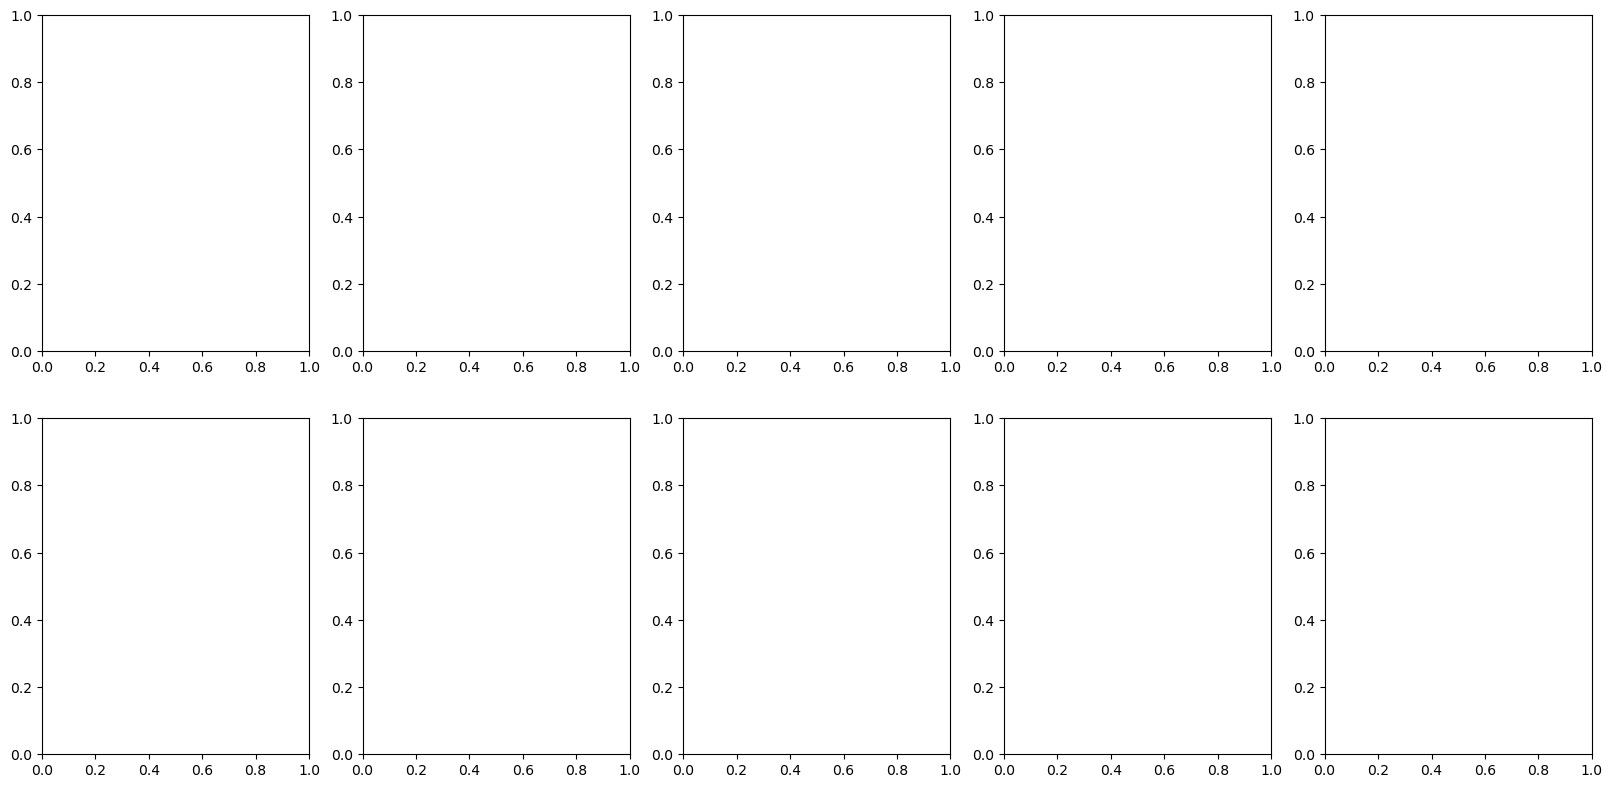

In [11]:
import os
import logging
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator

# --------------------------------------------------------
# Supplementary Figure 1 and 2 : YLG avoided (total years gained) by age group
# PLUS: one extra "Totals" panel per year (sum across age groups) with bars by scenario
# --------------------------------------------------------
rcParams["font.family"] = "DejaVu Sans"
warnings.simplefilter(action="ignore", category=FutureWarning)
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

# ---- user settings ----
base_path = "data/2-output-data"
plot_dir = os.path.join(base_path, "plots")
os.makedirs(plot_dir, exist_ok=True)

scenarios = ["S1", "S2", "S3", "S4"]
pollutants = ["ug_PM25_RH50", "ug_NO2"]
years = ["2030", "2050"]

pollutant_title = {"ug_PM25_RH50": "PM2.5", "ug_NO2": "NO2"}

age_bins = [-np.inf, 9, 19, 29, 39, 49, 59, 69, 79, 89, np.inf]
age_labels = ["0-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80-89", "90-99"]

# Scenario labels + colors (as requested)
scenario_labels = {"s1": "S1", "s2": "S2", "s3": "S3", "s4": "S4"}
scenario_colors = {"S1": "#9695FF", "S2": "#B47CC7", "S3": "#6ABF69", "S4": "#E88D67"}

# Base color used for the age-group panels (single series)
ylg_color = "#2E4057"

def mortality_csv_path(scenario, pollutant, year):
    for sc_variant in (scenario, scenario.lower(), scenario.upper()):
        for fname in ("mortality_chimere_mc.csv", "mortality_chimere.csv"):
            p = os.path.join(base_path, sc_variant, pollutant, str(year), fname)
            if os.path.exists(p):
                return p
    return None

def norm_cols(df):
    df = df.copy()
    df.columns = [str(c).strip().replace("\ufeff", "") for c in df.columns]
    return df

def pick_col(df, candidates):
    lowmap = {str(c).strip().lower(): c for c in df.columns}
    for c in candidates:
        hit = lowmap.get(str(c).lower())
        if hit is not None:
            return hit
    return None

# --------------------------------------------------------
# 1) LOAD MORTALITY (YLG) and aggregate by age group
# --------------------------------------------------------
mort_frames = []
for pol in pollutants:
    for sc in scenarios:
        for yr in years:
            p = mortality_csv_path(sc, pol, yr)
            if p is None:
                logging.warning(f"No mortality file for {sc}/{pol}/{yr}")
                continue
            logging.info(f"Loading mortality: {p}")
            d = norm_cols(pd.read_csv(p, dtype=str))
            d["scenario"] = sc
            d["pollutant"] = pol
            d["year"] = str(yr)
            mort_frames.append(d)

if not mort_frames:
    raise SystemExit("No mortality files found.")

mort = pd.concat(mort_frames, ignore_index=True, sort=False)

ylg_col = pick_col(mort, ["YLG", "ylg", "overall_YLG", "overall_ylg", "overall_Ylg"])
age_col = pick_col(mort, ["age", "Age", "AGE"])

if ylg_col is None:
    raise SystemExit(f"No YLG column found in mortality files. Columns: {mort.columns.tolist()}")

mort[ylg_col] = pd.to_numeric(mort[ylg_col], errors="coerce")

if age_col is not None:
    mort = mort.rename(columns={age_col: "age"})
    mort["age"] = pd.to_numeric(mort["age"], errors="coerce")
    mort["age_group"] = pd.cut(mort["age"], bins=age_bins, labels=age_labels, right=True)
else:
    raise SystemExit(
        "No age column found in mortality files, so age-group plotting is not possible.\n"
        "Add an age column (or age_group) to mortality CSV or modify loader to use it."
    )

mort_agg = (
    mort.groupby(["pollutant", "year", "scenario", "age_group"], dropna=False)[ylg_col]
        .sum()
        .reset_index()
        .rename(columns={ylg_col: "YLG_avoided"})
)
mort_agg["YLG_avoided"] = pd.to_numeric(mort_agg["YLG_avoided"], errors="coerce").fillna(0)

# Totals across age groups per (pollutant, year, scenario)
totals = (
    mort_agg.groupby(["pollutant", "year", "scenario"], dropna=False)["YLG_avoided"]
        .sum()
        .reset_index()
        .rename(columns={"YLG_avoided": "YLG_total"})
)

# --------------------------------------------------------
# 2) PLOT MATRIX: rows=years, cols=scenarios + one extra Totals column
# --------------------------------------------------------
for pol in sorted(mort_agg["pollutant"].dropna().unique().tolist()):
    sub_pol = mort_agg[mort_agg["pollutant"] == pol].copy()
    sub_tot = totals[totals["pollutant"] == pol].copy()
    if sub_pol.empty:
        continue

    nrows = len(years)
    ncols = len(scenarios) + 1  # +1 for the Totals column

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4.0 * ncols, 4.8 * nrows),
        sharex=False, sharey=False  # totals has different x; keep independent
    )
    axes = np.array(axes).reshape(nrows, ncols)

    # ---- Fill scenario-by-year panels (age-group bars)
    for i, yr in enumerate(years):
        for j, sc in enumerate(scenarios):
            ax = axes[i, j]
            block = sub_pol[(sub_pol["year"] == str(yr)) & (sub_pol["scenario"] == sc)].copy()

            if block.empty:
                ax.text(0.5, 0.5, f"No data\n{sc} {yr}", ha="center", va="center")
                ax.set_axis_off()
                continue

            block["age_group"] = pd.Categorical(block["age_group"], categories=age_labels, ordered=True)
            block = block.sort_values("age_group")

            x = np.arange(len(age_labels))
            width = 0.80
            vals = block["YLG_avoided"].to_numpy(dtype=float)

            ax.bar(x, vals, width=width, color=ylg_color, edgecolor="black", linewidth=0.4)

            ymax = float(np.nanmax(vals)) if len(vals) else 0.0
            ax.set_title(f"{sc} — {yr}", fontsize=13, weight="bold")
            ax.grid(axis="y", linestyle="--", alpha=0.35)
            ax.set_axisbelow(True)
            ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
            ax.set_ylim(0, ymax * 1.20 if ymax > 0 else 1)

            ax.set_xticks(x)
            ax.set_xticklabels(age_labels, rotation=40, ha="right", fontsize=10)

            if j == 0:
                ax.set_ylabel("YLG avoided (years)", fontsize=11)

    # ---- Fill totals-by-year panels (one panel per row, last column)
    for i, yr in enumerate(years):
        ax = axes[i, -1]  # last column
        block = sub_tot[sub_tot["year"] == str(yr)].copy()

        if block.empty:
            ax.text(0.5, 0.5, f"No totals\n{yr}", ha="center", va="center")
            ax.set_axis_off()
            continue

        # Ensure consistent scenario order
        block["scenario"] = pd.Categorical(block["scenario"], categories=scenarios, ordered=True)
        block = block.sort_values("scenario")

        x = np.arange(len(scenarios))
        width = 0.75
        vals = block["YLG_total"].to_numpy(dtype=float)

        bar_colors = [scenario_colors.get(sc, "#999999") for sc in block["scenario"].astype(str).tolist()]
        ax.bar(x, vals, width=width, color=bar_colors, edgecolor="black", linewidth=0.6)

        ymax = float(np.nanmax(vals)) if len(vals) else 0.0
        ax.set_title(f"Overall YLG — {yr}", fontsize=13, weight="bold")
        ax.grid(axis="y", linestyle="--", alpha=0.35)
        ax.set_axisbelow(True)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
        ax.set_ylim(0, ymax * 1.20 if ymax > 0 else 1)

        ax.set_xticks(x)
        ax.set_xticklabels(scenarios, rotation=0, ha="center", fontsize=10)

        # Keep y-label only on first column panels; totals column has none

    # ---- Legends
    scenario_handles = [
        Patch(facecolor=scenario_colors.get(sc, "#999999"), edgecolor="black", label=sc)
        for sc in scenarios
    ]

    fig.suptitle(
        f"YLG avoided by age group and Totals — {pollutant_title.get(pol, pol)}",
        fontsize=16, weight="bold", y=0.98
    )

    # Put legends on bottom (two rows)
    fig.legend(
        handles=scenario_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.005),
        ncol=4,
        frameon=True,
        framealpha=0.95,
        edgecolor="black",
        fontsize=10.5,
        title="Scenarios",
        title_fontsize=11,
    )

    fig.subplots_adjust(left=0.06, right=0.98, top=0.92, bottom=0.16, wspace=0.18, hspace=0.22)

    out_file = os.path.join(plot_dir, f"YLG_avoided_by_agegroup_with_totals_{pol}.png")
    fig.savefig(out_file, dpi=300, bbox_inches="tight")
    logging.info(f"Saved figure: {out_file}")
    plt.close(fig)

print("Done.")

In [ ]:
# --------------------------------------------------------
#   Supplementary Figure 3 and 4: DALY by age groups
# --------------------------------------------------------
import os
import logging
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator

# --------------------------------------------------------
#   DALY (by age group) = YLD (from morbidity_results.csv, summed by disease within age group)
#                       + YLG (from mortality_chimere_mc.csv, used as YLL averted proxy)
# --------------------------------------------------------
rcParams["font.family"] = "DejaVu Sans"
warnings.simplefilter(action="ignore", category=FutureWarning)
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

# ---- user settings ----
base_path = "data/2-output-data"
plot_dir = os.path.join(base_path, "plots")
os.makedirs(plot_dir, exist_ok=True)

scenarios = ["S1", "S2", "S3", "S4"]
pollutants = ["ug_PM25_RH50", "ug_NO2"]
years = ["2030", "2050"]

pollutant_title = {"ug_PM25_RH50": "PM2.5", "ug_NO2": "NO2"}

age_bins = [-np.inf, 9, 19, 29, 39, 49, 59, 69, 79, 89, np.inf]
age_labels = ["0-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80-89", "90-99"]

disease_age_groups = {
    "Hypertension": (18, 99),
    "Lung Cancer": (35, 99),
    "Asthma in children": (0, 17),
    "Asthma in adult": (18, 99),
    "COPD": (40, 99),
    "ALRI in children": (0, 12),
    "Stroke": (35, 99),
    "IHD events": (30, 99),
    "Diabetes T2": (45, 99),
}

# colors
colors = ["#F28E2B", "#E15759", "#76B7B2", "#59A14F", "#EDC948", "#B07AA1", "#FF9DA7", "#D4C23D", "#4E79A7"]
ylg_color = "#2E4057"  # base (YLG / YLL averted proxy)


def morbidity_csv_path(scenario, pollutant, year):
    for sc_variant in (scenario, scenario.lower(), scenario.upper()):
        p = os.path.join(base_path, sc_variant, pollutant, str(year), "morbidity_results.csv")
        if os.path.exists(p):
            return p
    return None


def mortality_csv_path(scenario, pollutant, year):
    for sc_variant in (scenario, scenario.lower(), scenario.upper()):
        for fname in ("mortality_chimere_mc.csv", "mortality_chimere.csv"):
            p = os.path.join(base_path, sc_variant, pollutant, str(year), fname)
            if os.path.exists(p):
                return p
    return None


def norm_cols(df):
    df = df.copy()
    df.columns = [str(c).strip().replace("\ufeff", "") for c in df.columns]
    return df


def pick_col(df, candidates):
    lowmap = {str(c).strip().lower(): c for c in df.columns}
    for c in candidates:
        hit = lowmap.get(str(c).lower())
        if hit is not None:
            return hit
    return None


def filter_morbidity_diseases(df):
    """Apply your disease-age filters (same logic as your original)."""
    out = []
    for disease_key, (min_age, max_age) in disease_age_groups.items():
        mask = df["disease"].str.contains(disease_key, case=False, na=False) | (df["disease"] == disease_key)
        dfd = df[mask].copy()
        if dfd.empty:
            continue
        dfd = dfd[(dfd["age"] >= min_age) & (dfd["age"] <= max_age)].copy()
        if dfd.empty:
            continue
        dfd["disease"] = disease_key
        out.append(dfd)
    if not out:
        return pd.DataFrame(columns=df.columns)
    return pd.concat(out, ignore_index=True, sort=False)


# --------------------------------------------------------
# 1) LOAD + AGGREGATE MORBIDITY -> YLD by age_group, disease
# --------------------------------------------------------
morb_frames = []
for pol in pollutants:
    for sc in scenarios:
        for yr in years:
            p = morbidity_csv_path(sc, pol, yr)
            if p is None:
                logging.warning(f"No morbidity_results.csv for {sc}/{pol}/{yr}")
                continue
            logging.info(f"Loading morbidity: {p}")
            d = norm_cols(pd.read_csv(p, dtype=str))
            d["scenario"] = sc
            d["pollutant"] = pol
            d["year"] = str(yr)
            morb_frames.append(d)

if not morb_frames:
    raise SystemExit("No morbidity files found.")

morb = pd.concat(morb_frames, ignore_index=True, sort=False)

age_col = pick_col(morb, ["age", "Age", "AGE"])
disease_col = pick_col(morb, ["disease", "Disease", "cause"])
yld_col = pick_col(morb, ["YLD_central", "YLD", "yld_central", "yld"])

if age_col is None or disease_col is None or yld_col is None:
    raise SystemExit(f"Missing required morbidity columns. Found: age={age_col}, disease={disease_col}, yld={yld_col}")

morb = morb.rename(columns={age_col: "age", disease_col: "disease"})
morb["age"] = pd.to_numeric(morb["age"], errors="coerce")
morb[yld_col] = pd.to_numeric(morb[yld_col], errors="coerce").fillna(0)
morb["disease"] = morb["disease"].astype(str).str.strip()

morb = filter_morbidity_diseases(morb)
if morb.empty:
    raise SystemExit("No morbidity rows left after disease-age filtering.")

morb["age_group"] = pd.cut(morb["age"], bins=age_bins, labels=age_labels, right=True)

morb_agg = (
    morb.groupby(["pollutant", "year", "scenario", "age_group", "disease"], dropna=False)[yld_col]
    .sum()
    .reset_index()
    .rename(columns={yld_col: "YLD_plot"})
)

# --------------------------------------------------------
# 2) LOAD MORTALITY
# --------------------------------------------------------
mort_frames = []
for pol in pollutants:
    for sc in scenarios:
        for yr in years:
            p = mortality_csv_path(sc, pol, yr)
            if p is None:
                logging.warning(f"No mortality_chimere.csv for {sc}/{pol}/{yr}")
                continue
            logging.info(f"Loading mortality: {p}")
            d = norm_cols(pd.read_csv(p, dtype=str))
            d["scenario"] = sc
            d["pollutant"] = pol
            d["year"] = str(yr)
            mort_frames.append(d)

if not mort_frames:
    raise SystemExit("No mortality files found.")

mort = pd.concat(mort_frames, ignore_index=True, sort=False)

ylg_col = pick_col(mort, ["YLG", "ylg", "overall_YLG", "overall_ylg", "overall_Ylg"])
mort_age_col = pick_col(mort, ["age", "Age", "AGE"])

if ylg_col is None:
    raise SystemExit("No YLG column found in mortality files.")

mort[ylg_col] = pd.to_numeric(mort[ylg_col], errors="coerce")

if mort_age_col is not None:
    mort = mort.rename(columns={mort_age_col: "age"})
    mort["age"] = pd.to_numeric(mort["age"], errors="coerce")
    mort["age_group"] = pd.cut(mort["age"], bins=age_bins, labels=age_labels, right=True)

    mort_agg = (
        mort.groupby(["pollutant", "year", "scenario", "age_group"], dropna=False)[ylg_col]
        .sum()
        .reset_index()
        .rename(columns={ylg_col: "YLG_plot"})
    )
else:
    mort_overall = (
        mort.groupby(["pollutant", "year", "scenario"], dropna=False)[ylg_col]
        .apply(lambda s: s.dropna().iloc[0] if not s.dropna().empty else np.nan)
        .reset_index()
        .rename(columns={ylg_col: "YLG_plot"})
    )
    mort_agg = mort_overall.merge(pd.DataFrame({"age_group": age_labels}), how="cross")

mort_agg["YLG_plot"] = pd.to_numeric(mort_agg["YLG_plot"], errors="coerce").fillna(0)

# --------------------------------------------------------
# 3) MERGE + COMPUTE DALY by age group
# --------------------------------------------------------
agg = morb_agg.merge(mort_agg, on=["pollutant", "year", "scenario", "age_group"], how="left")
agg["YLD_plot"] = pd.to_numeric(agg["YLD_plot"], errors="coerce").fillna(0)
agg["YLG_plot"] = pd.to_numeric(agg["YLG_plot"], errors="coerce").fillna(0)

yld_pivot = (
    agg.pivot_table(
        index=["pollutant", "year", "scenario", "age_group"],
        columns="disease",
        values="YLD_plot",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)

ylg_by_age = (
    mort_agg.groupby(["pollutant", "year", "scenario", "age_group"], dropna=False)["YLG_plot"]
    .sum()
    .reset_index()
)
plot_df = yld_pivot.merge(ylg_by_age, on=["pollutant", "year", "scenario", "age_group"], how="left")
plot_df["YLG_plot"] = plot_df["YLG_plot"].fillna(0)

# --------------------------------------------------------
# 4) PLOT: rows = years, cols = scenarios
# --------------------------------------------------------
for pol in sorted(plot_df["pollutant"].dropna().unique().tolist()):
    sub_pol = plot_df[plot_df["pollutant"] == pol].copy()
    if sub_pol.empty:
        continue

    diseases_present = (
        agg[agg["pollutant"] == pol]
        .groupby("disease", as_index=False)["YLD_plot"].sum()
        .sort_values("YLD_plot", ascending=False)
    )
    disease_list = diseases_present.loc[diseases_present["YLD_plot"] > 0, "disease"].tolist()
    if not disease_list:
        disease_list = diseases_present["disease"].tolist()

    disease_color_map = {d: colors[i % len(colors)] for i, d in enumerate(disease_list)}

    nrows = len(years)
    ncols = len(scenarios)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.0 * ncols, 4.8 * nrows), sharex=True, sharey=True)
    axes = np.array(axes).reshape(nrows, ncols)

    for i, yr in enumerate(years):
        for j, sc in enumerate(scenarios):
            ax = axes[i, j]
            block = sub_pol[(sub_pol["year"] == str(yr)) & (sub_pol["scenario"] == sc)].copy()

            if block.empty:
                ax.text(0.5, 0.5, f"No data\n{sc} {yr}", ha="center", va="center")
                ax.set_axis_off()
                continue

            block["age_group"] = pd.Categorical(block["age_group"], categories=age_labels, ordered=True)
            block = block.sort_values("age_group")

            x = np.arange(len(age_labels))
            width = 0.80

            ylg_vals = block["YLG_plot"].to_numpy(dtype=float)
            ax.bar(x, ylg_vals, width=width, color=ylg_color, edgecolor="black", linewidth=0.4)

            bottom = ylg_vals.copy()
            for dis in disease_list:
                if dis not in block.columns:
                    continue
                vals = block[dis].to_numpy(dtype=float)
                if np.allclose(vals, 0):
                    continue
                ax.bar(x, vals, bottom=bottom, width=width, color=disease_color_map.get(dis, "#999999"))
                bottom += vals

            total = bottom
            ymax = float(np.max(total)) if len(total) else 0.0

            ax.set_title(f"{sc} — {yr}", fontsize=13, weight="bold")
            ax.grid(axis="y", linestyle="--", alpha=0.35)
            ax.set_axisbelow(True)
            ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
            ax.set_ylim(0, ymax * 1.15 if ymax > 0 else 1)

            ax.set_xticks(x)
            ax.set_xticklabels(age_labels, rotation=40, ha="right", fontsize=10)

            if j == 0:
                ax.set_ylabel("DALYs averted (YLL + YLD)", fontsize=11)

    legend_handles = [Patch(facecolor=ylg_color, edgecolor="black", label="YLL (mortality)")]
    legend_handles += [Patch(facecolor=disease_color_map[d], label=d) for d in disease_list]

    fig.suptitle(f"DALYs averted by age group — {pollutant_title.get(pol, pol)}", fontsize=16, weight="bold", y=0.98)
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.01),
        ncol=min(8, max(1, len(legend_handles))),
        frameon=True,
        framealpha=0.95,
        edgecolor="black",
        fontsize=10.5,
        title="Components (YLL + YLD)",
        title_fontsize=11,
    )

    fig.subplots_adjust(left=0.06, right=0.98, top=0.92, bottom=0.14, wspace=0.12, hspace=0.22)

    out_file = os.path.join(plot_dir, f"DALY_by_agegroup_YLDplusYLG_{pol}.png")
    fig.savefig(out_file, dpi=300, bbox_inches="tight")
    logging.info(f"Saved figure: {out_file}")
    plt.close(fig)

print("Done.")


In [ ]:
#---------------------------------------------------
#Supplementary Figure 5 and 6: Heatmap by scenario for each pollutant and year
#---------------------------------------------------
"""
Heatmaps:
- Per year (2030, 2050) and pollutant (PM2.5, NO2), plot 3 heatmaps (outcomes x scenarios):
  1) Events prevented (Deaths for mortality row; Cases for morbidity rows; plus a "TOTAL morbidity" row)
  2) Direct medical costs prevented (M€) (morbidity + a "TOTAL morbidity" row; mortality is NaN)
  3) Intangible costs prevented (M€) where Intangible = YLL + YLD (mortality + morbidity + total morbidity)
"""

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# Config
# -------------------------
INFILE = os.path.join("data", "2-output-data", "economic_summary_morbidity_sensitivity.csv")
OUTDIR = os.path.join("data", "2-output-data", "plots")
os.makedirs(OUTDIR, exist_ok=True)

SCEN_ORDER = ["s1", "s2", "s3", "s4"]
POLL_ORDER = ["PM2.5", "NO2"]
YEAR_ORDER = ["2030", "2050"]

MORT_DISEASE_LABEL = "All-cause mortality (main)"
TOTAL_MORB_LABEL = "TOTAL morbidity (excl. mortality)"

# Outcomes to display individually (optional).
# We will add TOTAL_MORB_LABEL automatically.
OUTCOME_ORDER = [
    MORT_DISEASE_LABEL,
    "Hypertension",
    "Diabetes T2",
    "COPD",
    "Stroke",
    "IHD events",
    "AMI events",
    "Lung Cancer",
    "Asthma in children",
    "Asthma in adult",
    "ALRI in children",
    TOTAL_MORB_LABEL,
]

OUTCOME_LABELS = {
    MORT_DISEASE_LABEL: "All-cause mortality",
    "Diabetes T2": "Type 2 diabetes",
    "Asthma in adult": "Asthma in adults",
    TOTAL_MORB_LABEL: "TOTAL",
}

# -------------------------
# Helpers
# -------------------------
_num_pat = re.compile(r"^\s*([0-9,\.]+)\s*\[\s*([0-9,\.]+)\s*-\s*([0-9,\.]+)\s*\]\s*$")


def parse_est_ci(s):
    """Parse '19,250 [13,700-24,800]' -> (central, lci, uci) floats."""
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return (np.nan, np.nan, np.nan)
    s = str(s).strip()
    if not s:
        return (np.nan, np.nan, np.nan)
    m = _num_pat.match(s)
    if not m:
        return (np.nan, np.nan, np.nan)
    c, l, u = m.groups()
    c = float(c.replace(",", ""))
    l = float(l.replace(",", ""))
    u = float(u.replace(",", ""))
    return (c, l, u)


def _to_float(x):
    if x is None:
        return np.nan
    if isinstance(x, str) and x.strip() == "":
        return np.nan
    try:
        return float(x)
    except Exception:
        return np.nan


def clean_scenario(sc):
    return str(sc).strip().lower()


def outcome_display_name(outcome):
    return OUTCOME_LABELS.get(outcome, outcome)


def is_mortality_row(disease):
    return str(disease).strip() == MORT_DISEASE_LABEL


def is_any_mortality_variant(disease):
    # excludes sensitivity rows too (if present)
    return str(disease).lower().startswith("all-cause mortality")


def safe_sum(series):
    # sum treating all-NaN as NaN (min_count=1) but allow 0 for empty after fill
    return series.sum(min_count=1)


def fmt_ci(c, l, u, digits=0):
    if c is None or (isinstance(c, float) and np.isnan(c)):
        return "--"
    if digits == 0:
        return f"{c:,.0f} [{l:,.0f}–{u:,.0f}]"
    return f"{c:,.{digits}f} [{l:,.{digits}f}–{u:,.{digits}f}]"


def fmt_millions_ci(c, l, u):
    if c is None or (isinstance(c, float) and np.isnan(c)):
        return "--"
    return f"{c:,.0f} [{l:,.0f}–{u:,.0f}]"


# -------------------------
# Load and preprocess
# -------------------------
df = pd.read_csv(INFILE)

# Filter no_lag only
df = df[df["Lag"].astype(str).str.lower() == "no_lag"].copy()
if df.empty:
    raise RuntimeError("No rows found with Lag == 'no_lag'. Check your CSV.")

df["Scenario"] = df["Scenario"].apply(clean_scenario)
df["Year"] = df["Year"].astype(str)
df["Pollutant"] = df["Pollutant"].astype(str)
df["Disease"] = df["Disease"].astype(str)

# Parse cases/deaths strings into numeric
cases = df["Avoided Cases"].apply(parse_est_ci)
df[["Cases_c", "Cases_l", "Cases_u"]] = pd.DataFrame(cases.tolist(), index=df.index)

deaths = df["Deaths Avoided"].apply(parse_est_ci)
df[["Deaths_c", "Deaths_l", "Deaths_u"]] = pd.DataFrame(deaths.tolist(), index=df.index)

# Costs: numeric in M€ columns; coerce blank -> NaN
df["DirectMed_c_MEUR"] = df["Direct Med Cost (M€)"].apply(_to_float)
df["DirectMed_l_MEUR"] = df["Direct Med Cost LCI (M€)"].apply(_to_float)
df["DirectMed_u_MEUR"] = df["Direct Med Cost UCI (M€)"].apply(_to_float)

df["IntYLL_c_MEUR"] = df["Intangible Cost YLL (M€)"].apply(_to_float)
df["IntYLL_l_MEUR"] = df["Intangible Cost YLL LCI (M€)"].apply(_to_float)
df["IntYLL_u_MEUR"] = df["Intangible Cost YLL UCI (M€)"].apply(_to_float)

df["IntYLD_c_MEUR"] = df["Intangible Cost YLD (M€)"].apply(_to_float)
df["IntYLD_l_MEUR"] = df["Intangible Cost YLD LCI (M€)"].apply(_to_float)
df["IntYLD_u_MEUR"] = df["Intangible Cost YLD UCI (M€)"].apply(_to_float)

# Combined intangible = YLL + YLD (treat NaN as 0 for the sum)
for b in ["c", "l", "u"]:
    df[f"IntTotal_{b}_MEUR"] = df[f"IntYLL_{b}_MEUR"].fillna(0) + df[f"IntYLD_{b}_MEUR"].fillna(0)

# Keep only scenarios/pollutants/years we want
df = df[df["Scenario"].isin(SCEN_ORDER) & df["Pollutant"].isin(POLL_ORDER) & df["Year"].isin(YEAR_ORDER)].copy()

# -------------------------
# Build "TOTAL morbidity" rows (per scenario/pollutant/year)
# -------------------------
morb = df[~df["Disease"].apply(is_any_mortality_variant)].copy()

tot_rows = []
group_cols = ["Scenario", "Pollutant", "Year"]
for (sc, pol, yr), g in morb.groupby(group_cols, dropna=False):
    tot_rows.append({
        "Scenario": sc,
        "Pollutant": pol,
        "Year": yr,
        "Disease": TOTAL_MORB_LABEL,
        "Cases_c": safe_sum(g["Cases_c"]),
        "Cases_l": safe_sum(g["Cases_l"]),
        "Cases_u": safe_sum(g["Cases_u"]),
        "Deaths_c": np.nan,
        "Deaths_l": np.nan,
        "Deaths_u": np.nan,
        "DirectMed_c_MEUR": safe_sum(g["DirectMed_c_MEUR"]),
        "DirectMed_l_MEUR": safe_sum(g["DirectMed_l_MEUR"]),
        "DirectMed_u_MEUR": safe_sum(g["DirectMed_u_MEUR"]),
        "IntTotal_c_MEUR": safe_sum(g["IntTotal_c_MEUR"]),
        "IntTotal_l_MEUR": safe_sum(g["IntTotal_l_MEUR"]),
        "IntTotal_u_MEUR": safe_sum(g["IntTotal_u_MEUR"]),
        # keep these for consistency (not used directly)
        "IntYLL_c_MEUR": np.nan,
        "IntYLL_l_MEUR": np.nan,
        "IntYLL_u_MEUR": np.nan,
        "IntYLD_c_MEUR": safe_sum(g["IntYLD_c_MEUR"]),
        "IntYLD_l_MEUR": safe_sum(g["IntYLD_l_MEUR"]),
        "IntYLD_u_MEUR": safe_sum(g["IntYLD_u_MEUR"]),
    })

tot_df = pd.DataFrame(tot_rows)

# For plotting, merge original + totals and keep only outcomes we care about
plot_df = pd.concat([df, tot_df], ignore_index=True)

plot_df["OutcomeLabel"] = plot_df["Disease"].apply(outcome_display_name)


# If both "Diabetes T2" and "Type 2 diabetes" appear, you might get duplicates.
# We'll keep whichever exists; pivot_table with aggfunc='max' resolves duplicates safely.
def _dedup_keep_max(pv):
    return pv.groupby(level=0).max()


# -------------------------
# Plot heatmaps
# -------------------------
sns.set_theme(style="whitegrid")


def pivot_metric(dd, value_col):
    pv = dd.pivot_table(
        index="OutcomeLabel",
        columns="Scenario",
        values=value_col,
        aggfunc="max",  # robust to duplicates
    )
    # order rows and cols
    ordered_rows = [outcome_display_name(o) for o in OUTCOME_ORDER if outcome_display_name(o) in pv.index]
    pv = pv.reindex(ordered_rows)
    pv = pv.reindex(columns=SCEN_ORDER)
    return pv


def make_heatmaps_for_year(year):
    d = plot_df[plot_df["Year"] == str(year)].copy()
    if d.empty:
        print(f"[WARN] No data for year {year}")
        return

    for pol in POLL_ORDER:
        dd = d[d["Pollutant"] == pol].copy()
        if dd.empty:
            continue

        # Events prevented:
        # - mortality uses Deaths_c
        # - morbidity uses Cases_c
        dd["Events_c"] = np.where(
            dd["Disease"].apply(is_mortality_row),
            dd["Deaths_c"],
            dd["Cases_c"],
        )

        pv_events = pivot_metric(dd, "Events_c")
        pv_tang = pivot_metric(dd, "DirectMed_c_MEUR")
        pv_intang = pivot_metric(dd, "IntTotal_c_MEUR")

        fig, axes = plt.subplots(1, 3, figsize=(20.5, 7))
        fig.suptitle(f" Health and Economic Benefits: {pol} — {year}", fontsize=14, y=1.02, fontweight="bold")
        fig.subplots_adjust(
            top=0.9,
            bottom=0.05,
            left=0.05,
            right=0.965,
            wspace=0.42,
            hspace=0.3,
        )

        # Heatmap 1: events
        sns.heatmap(
            pv_events,
            ax=axes[0],
            cmap="YlGnBu",
            linewidths=0.4,
            linecolor="white",
            annot=True,
            fmt=".0f",
            cbar_kws={"label": "Prevented events (cases or deaths)", "pad": 0.03, "shrink": 0.92},
        )
        axes[0].set_title("Events prevented")
        axes[0].set_xlabel("Scenario")
        axes[0].set_ylabel("Outcome")

        # Heatmap 2: tangible costs (M€)
        sns.heatmap(
            pv_tang,
            ax=axes[1],
            cmap="YlGnBu",
            linewidths=0.4,
            linecolor="white",
            annot=True,
            fmt=".0f",
            cbar_kws={"label": "Direct medical costs prevented (M€)", "pad": 0.03, "shrink": 0.92},
        )
        axes[1].set_title("Direct medical costs prevented")
        axes[1].set_xlabel("Scenario")
        axes[1].set_ylabel("")

        # Heatmap 3: intangible costs (YLL+YLD)
        sns.heatmap(
            pv_intang,
            ax=axes[2],
            cmap="YlGnBu",
            linewidths=0.4,
            linecolor="white",
            annot=True,
            fmt=".0f",
            cbar_kws={"label": "Intangible costs prevented (M€, YLL+YLD)", "pad": 0.03, "shrink": 0.92},
        )
        axes[2].set_title("Intangible costs prevented")
        axes[2].set_xlabel("Scenario")
        axes[2].set_ylabel("")

        out_png = os.path.join(OUTDIR, f"heatmaps_{pol.replace('.', '')}_{year}_no_lag_v2.png")
        fig.savefig(out_png, dpi=300, bbox_inches="tight")
        plt.close(fig)
        print(f"[OK] Saved heatmaps: {out_png}")


# -------------------------
# Run
# -------------------------
for y in YEAR_ORDER:
    make_heatmaps_for_year(y)
print(f"\nDone. Outputs saved in: {OUTDIR}")
